# NB-03 · SimCLR + SegFormer-B0 for Brain Tumour MRI Semantic Segmentation

**CSE 438: Digital Image Processing**  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Dept of CSE  
**Institution:** East West University (EWU)

---

## Purpose of the notebook

This notebook constructs a two-stage learning pipeline for binary semantic segmentation of brain tumour MRI images in **COCO polygon format**.

- **Stage A — SimCLR representation learning:** the **SegFormer MiT-B0 encoder itself** learns representations from two augmented views of each MRI image.
- **Stage B — SegFormer fine-tuning:** the learned MiT-B0 encoder parameters are transferred directly into `SegformerForSemanticSegmentation` for tumour-mask prediction.

The method intentionally avoids pretraining an unrelated ResNet and attempting to transfer it into SegFormer. In this experiment, the representation learner and the downstream segmentation encoder are the same architecture.

### Binary mask convention

| Label | Pixel interpretation |
|---:|---|
| 0 | Background |
| 1 | Tumour region |

### Kaggle execution safeguards

The notebook uses standard contiguous tensors and does not execute `channels_last` memory conversions. Before training, a CUDA kernel probe is executed. AMP is enabled only if that probe succeeds. For numerical stability, the NT-Xent objective and segmentation loss are computed in `float32`, while eligible model forward operations may use AMP on a functional GPU.

## Learning outcomes

Students will be able to:

1. merge COCO tumour polygons into binary semantic masks;
2. explain direct MiT-B0 encoder transfer between SimCLR and SegFormer;
3. train a two-class semantic segmenter using cross-entropy plus foreground Dice loss;
4. interpret probability maps, predicted-mask overlays, error maps, spatial feature responses, and t-SNE plots;
5. distinguish visual exploratory evidence from Dice and IoU-based segmentation evaluation.

In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================
# No PyTorch, torchvision, or CUDA installation commands are used.
# Hosted accelerator package stacks should not be modified casually.

import copy
import json
import math
import random
import warnings
from collections import defaultdict
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageDraw

from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

try:
    import transformers
    from transformers import SegformerConfig, SegformerModel, SegformerForSemanticSegmentation
except ImportError as exc:
    raise ImportError(
        "SegFormer requires the Hugging Face transformers package. "
        "Select a Kaggle runtime image containing transformers, or attach "
        "an approved wheel as an input without altering the CUDA stack."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class Config:
    data_root: Path = Path(
        "/kaggle/input/datasets/pkdarabi/"
        "brain-tumor-image-dataset-semantic-segmentation"
    )
    output_dir: Path = Path("/kaggle/working/NB03_SimCLR_SegFormer_B0_outputs")

    backbone_checkpoint: str = "nvidia/mit-b0"
    image_size: int = 224
    projection_dim: int = 128
    temperature: float = 0.20

    ssl_epochs: int = 10
    segmentation_epochs: int = 10
    ssl_batch_size: int = 16
    segmentation_batch_size: int = 8

    learning_rate_ssl: float = 3e-4
    learning_rate_segmentation: float = 2e-4
    weight_decay: float = 1e-4
    ce_weight: float = 1.0
    dice_weight: float = 1.0

    num_workers: int = 0
    seed: int = 438
    tsne_max_samples: int = 240
    probability_threshold: float = 0.50


cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Output directory:", cfg.output_dir)


PyTorch: 2.10.0+cu128
Transformers: 5.0.0
Output directory: /kaggle/working/NB03_SimCLR_SegFormer_B0_outputs


In [2]:
# ============================================================
# 2. Reproducibility, CUDA compatibility probe, and safe AMP
# ============================================================

def seed_everything(seed: int) -> None:
    """Set seeds so classroom comparisons are easier to reproduce."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def configure_safe_device() -> Tuple[torch.device, bool]:
    """
    Select CUDA only after ordinary kernels execute successfully.

    Some Kaggle sessions expose CUDA while the installed build cannot
    execute kernels on the allocated GPU. This probe detects that case
    before a long training stage begins.
    """
    if not torch.cuda.is_available():
        print("CUDA is not available. Training will run on CPU.")
        return torch.device("cpu"), False

    try:
        candidate = torch.device("cuda")
        x = torch.randn(2, 3, 32, 32, device=candidate).contiguous()
        layer = nn.Conv2d(3, 4, kernel_size=3, padding=1).to(candidate)
        y = layer(x)
        y.float().mean().backward()
        torch.cuda.synchronize()
        print("CUDA probe passed:", torch.cuda.get_device_name(0))
        return candidate, True
    except Exception as error:
        print("CUDA is visible but its kernel probe failed; using CPU.")
        print("Diagnostic message:", error)
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        return torch.device("cpu"), False


def amp_context():
    """Use autocast only on a CUDA device that passed the probe."""
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def build_grad_scaler():
    """Create a scaler while supporting more than one PyTorch AMP namespace."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


seed_everything(cfg.seed)
DEVICE, CUDA_IS_FUNCTIONAL = configure_safe_device()
AMP_ENABLED = bool(DEVICE.type == "cuda" and CUDA_IS_FUNCTIONAL)

print("Selected device:", DEVICE)
print("AMP enabled:", AMP_ENABLED)


CUDA probe passed: Tesla T4
Selected device: cuda
AMP enabled: True


## Stage 0 · COCO polygons to binary masks

For semantic segmentation, all tumour polygon instances assigned to one MRI image are merged into a single foreground mask. This removes instance identity while retaining the region required for pixel-level tumour localisation.

In [3]:
# ============================================================
# 3. COCO parsing and binary-mask generation
# ============================================================

EXPECTED_SPLITS = ["train", "valid", "test"]


class CocoBinaryIndex:
    """Index one COCO split and draw all polygon annotations into one mask."""

    def __init__(self, split_dir: Path):
        self.split_dir = Path(split_dir)
        self.annotation_path = self.split_dir / "_annotations.coco.json"

        if not self.annotation_path.exists():
            raise FileNotFoundError(f"Missing annotation file: {self.annotation_path}")

        with open(self.annotation_path, "r", encoding="utf-8") as handle:
            coco = json.load(handle)

        annotations_by_image = defaultdict(list)
        for annotation in coco.get("annotations", []):
            annotations_by_image[annotation["image_id"]].append(annotation)

        self.categories = coco.get("categories", [])
        self.records = []

        for item in coco.get("images", []):
            image_path = self.split_dir / item["file_name"]
            if not image_path.exists():
                candidates = list(self.split_dir.rglob(Path(item["file_name"]).name))
                if not candidates:
                    raise FileNotFoundError(f"Image listed in JSON not found: {item['file_name']}")
                image_path = candidates[0]

            self.records.append(
                {
                    "image_id": item["id"],
                    "file_name": item["file_name"],
                    "path": image_path,
                    "annotations": annotations_by_image[item["id"]],
                }
            )

        if not self.records:
            raise RuntimeError(f"No COCO image records found in {self.annotation_path}")

    def __len__(self) -> int:
        return len(self.records)

    def load_image_and_mask(self, index: int) -> Tuple[Image.Image, Image.Image]:
        record = self.records[index]
        image = Image.open(record["path"]).convert("RGB")
        mask = Image.new("L", image.size, color=0)
        draw = ImageDraw.Draw(mask)

        for annotation in record["annotations"]:
            segmentation = annotation.get("segmentation", [])
            if not isinstance(segmentation, list):
                raise ValueError(
                    "This instructional notebook expects polygon-based COCO annotations; "
                    "an RLE annotation was encountered."
                )

            for polygon in segmentation:
                if len(polygon) < 6:
                    continue
                points = [
                    (float(polygon[position]), float(polygon[position + 1]))
                    for position in range(0, len(polygon) - 1, 2)
                ]
                draw.polygon(points, fill=1, outline=1)

        return image, mask


def validate_dataset(data_root: Path) -> Dict[str, CocoBinaryIndex]:
    if not data_root.exists():
        raise FileNotFoundError(
            f"Dataset root not found: {data_root}\n"
            "Attach the dataset using the exact Kaggle input path stated above."
        )

    indexed_splits = {}
    for split in EXPECTED_SPLITS:
        indexed_splits[split] = CocoBinaryIndex(data_root / split)
    return indexed_splits


indexes = validate_dataset(cfg.data_root)

split_table = pd.DataFrame(
    {
        "Split": EXPECTED_SPLITS,
        "Number of images": [len(indexes[name]) for name in EXPECTED_SPLITS],
        "Annotation file": [indexes[name].annotation_path.name for name in EXPECTED_SPLITS],
    }
)
display(split_table)
print("Training COCO categories:", indexes["train"].categories)


,Split,Number of images,Annotation file
0,train,1502,_annotations.coco.json
1,valid,429,_annotations.coco.json
2,test,215,_annotations.coco.json


Training COCO categories: [{'id': 0, 'name': 'Tumor', 'supercategory': 'none'}, {'id': 1, 'name': '0', 'supercategory': 'Tumor'}, {'id': 2, 'name': '1', 'supercategory': 'Tumor'}]


Mask coverage: train:   0%|          | 0/1502 [00:00<?, ?it/s]

Mask coverage: valid:   0%|          | 0/429 [00:00<?, ?it/s]

Mask coverage: test:   0%|          | 0/215 [00:00<?, ?it/s]

,Split,Images,Mean foreground %,Median foreground %,Maximum foreground %
0,train,1502,3.711,2.985,31.535000
1,valid,429,3.723,3.043,16.306999
2,test,215,3.711,2.856,17.481001


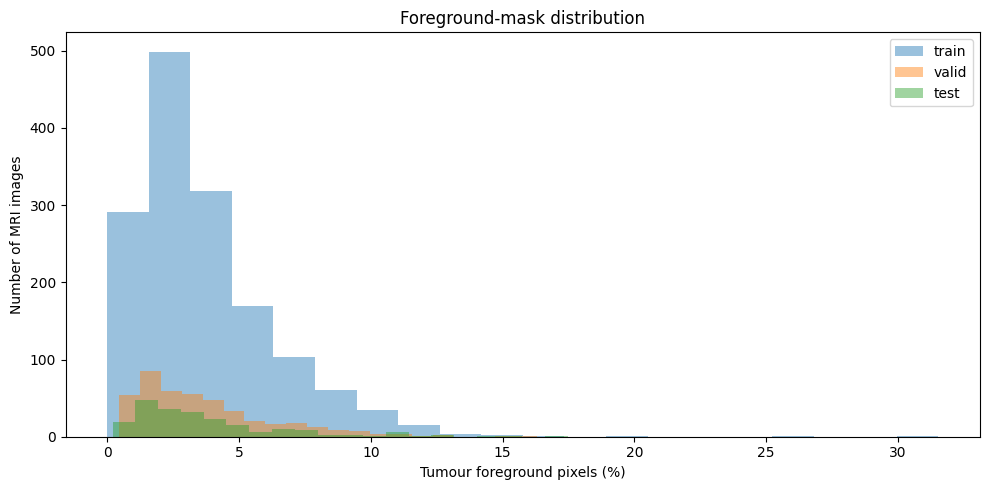

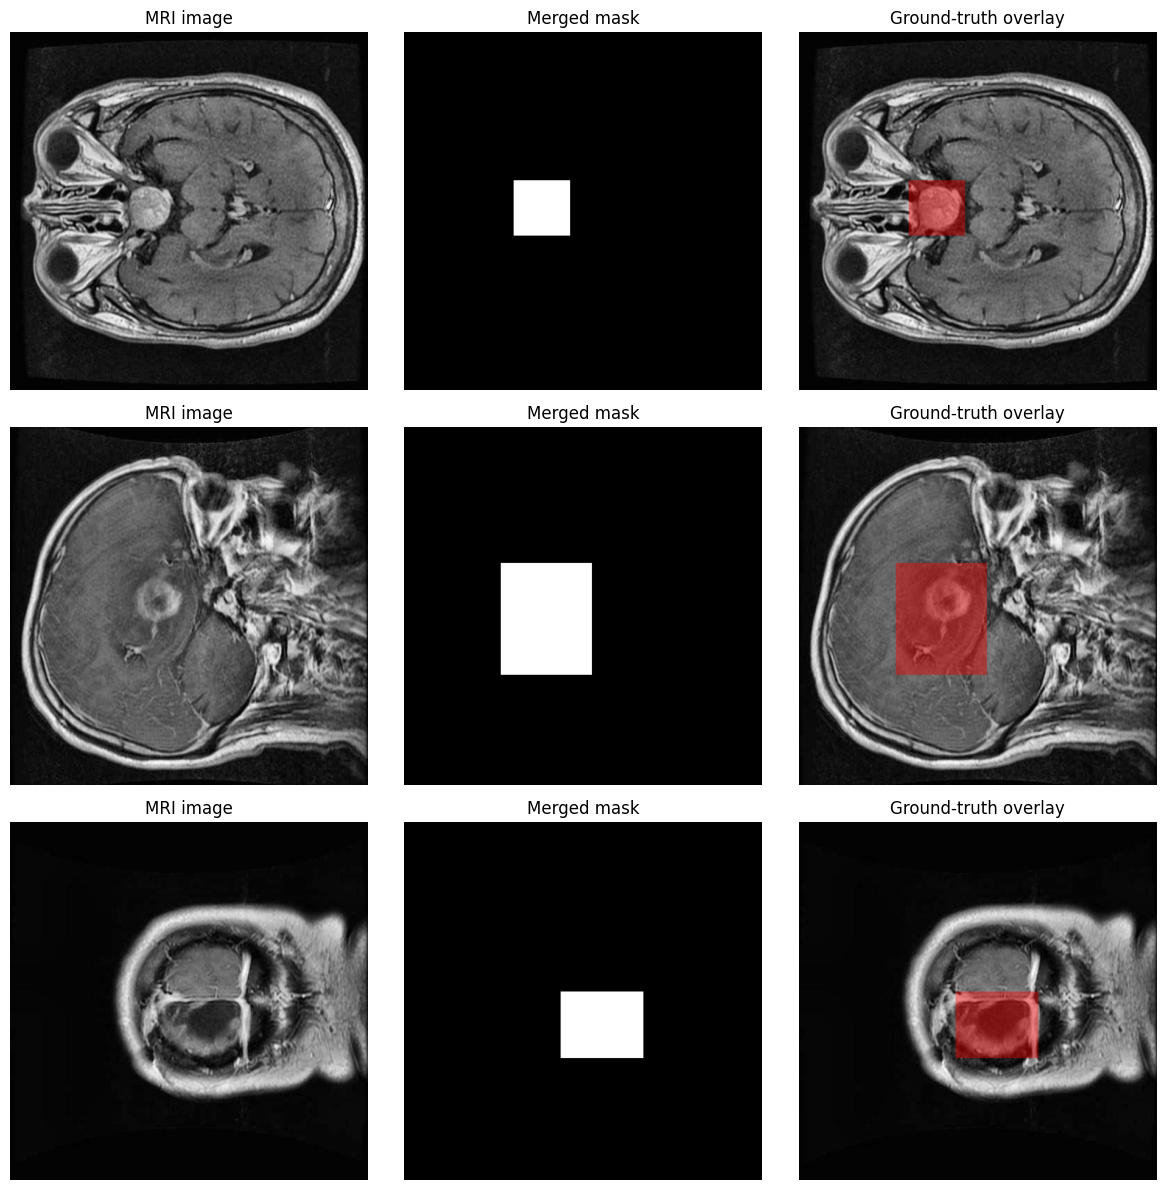

In [4]:
# ============================================================
# 4. Mask statistics and overlay examples
# ============================================================

def foreground_ratios(index: CocoBinaryIndex) -> np.ndarray:
    ratios = []
    for row in tqdm(range(len(index)), desc=f"Mask coverage: {index.split_dir.name}", leave=False):
        _, mask = index.load_image_and_mask(row)
        ratios.append(np.asarray(mask, dtype=np.uint8).mean())
    return np.asarray(ratios, dtype=np.float32)


def overlay_mask(image: np.ndarray, mask: np.ndarray, alpha: float = 0.42) -> np.ndarray:
    output = image.astype(np.float32).copy()
    colour = np.zeros_like(output)
    colour[..., 0] = 255
    foreground = mask.astype(bool)
    output[foreground] = (1 - alpha) * output[foreground] + alpha * colour[foreground]
    return np.clip(output, 0, 255).astype(np.uint8)


coverage = {name: foreground_ratios(indexes[name]) for name in EXPECTED_SPLITS}

coverage_table = pd.DataFrame(
    [
        {
            "Split": name,
            "Images": len(values),
            "Mean foreground %": 100 * values.mean(),
            "Median foreground %": 100 * np.median(values),
            "Maximum foreground %": 100 * values.max(),
        }
        for name, values in coverage.items()
    ]
)
display(coverage_table.round(3))

plt.figure(figsize=(10, 5))
for split, ratios in coverage.items():
    plt.hist(100 * ratios, bins=20, alpha=0.45, label=split)
plt.xlabel("Tumour foreground pixels (%)")
plt.ylabel("Number of MRI images")
plt.title("Foreground-mask distribution")
plt.legend()
plt.tight_layout()
plt.savefig(cfg.output_dir / "mask_coverage_distribution.png", dpi=180)
plt.show()

rng = np.random.default_rng(cfg.seed)
chosen = rng.choice(len(indexes["train"]), size=min(3, len(indexes["train"])), replace=False)
fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4 * len(chosen)))
if len(chosen) == 1:
    axes = np.expand_dims(axes, 0)

for row, item_index in enumerate(chosen):
    image, mask = indexes["train"].load_image_and_mask(int(item_index))
    image_array, mask_array = np.asarray(image), np.asarray(mask)
    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title("MRI image")
    axes[row, 1].imshow(mask_array, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("Merged mask")
    axes[row, 2].imshow(overlay_mask(image_array, mask_array))
    axes[row, 2].set_title("Ground-truth overlay")
    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.savefig(cfg.output_dir / "raw_mask_overlays.png", dpi=180, bbox_inches="tight")
plt.show()


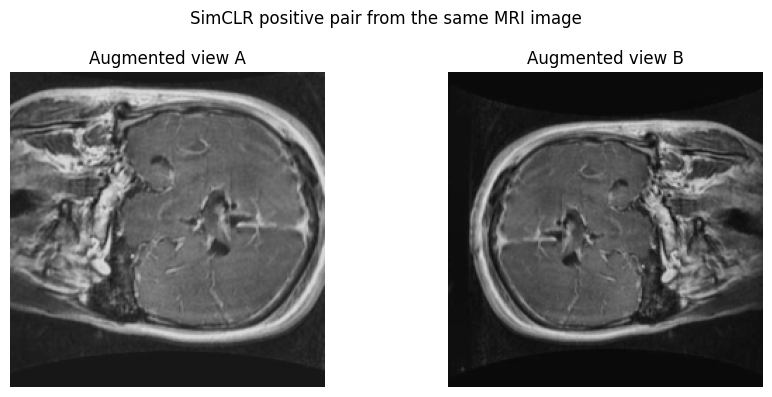

SimCLR batches: 93
Segmentation train batches: 188


In [5]:
# ============================================================
# 5. Transformations, datasets, and loaders
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class PairedSegmentationTransform:
    """Apply corresponding spatial transformations to image and class mask."""

    def __init__(self, image_size: int, training: bool):
        self.image_size = image_size
        self.training = training

    def __call__(self, image: Image.Image, mask: Image.Image):
        image = TF.resize(
            image, [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR, antialias=True
        )
        mask = TF.resize(
            mask, [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST
        )

        if self.training and random.random() < 0.5:
            image, mask = TF.hflip(image), TF.hflip(mask)

        if self.training and random.random() < 0.35:
            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        image_tensor = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
        mask_tensor = torch.as_tensor(np.asarray(mask, dtype=np.uint8).copy(), dtype=torch.long)
        return image_tensor.contiguous(), (mask_tensor > 0).long().contiguous()


simclr_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            cfg.image_size, scale=(0.65, 1.0), ratio=(0.90, 1.10),
            interpolation=InterpolationMode.BILINEAR, antialias=True
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply(
            [transforms.RandomRotation(12, interpolation=InterpolationMode.BILINEAR)], p=0.40
        ),
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.25, contrast=0.25)], p=0.55
        ),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.4))], p=0.35
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class SimCLRDataset(Dataset):
    def __init__(self, index: CocoBinaryIndex):
        self.index = index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, row):
        image, _ = self.index.load_image_and_mask(row)
        return simclr_transform(image).contiguous(), simclr_transform(image).contiguous()


class SegmentationDataset(Dataset):
    def __init__(self, index: CocoBinaryIndex, training: bool):
        self.index = index
        self.transform = PairedSegmentationTransform(cfg.image_size, training=training)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, row):
        image, mask = self.index.load_image_and_mask(row)
        image, mask = self.transform(image, mask)
        return image, mask, self.index.records[row]["file_name"]


simclr_dataset = SimCLRDataset(indexes["train"])
train_dataset = SegmentationDataset(indexes["train"], training=True)
valid_dataset = SegmentationDataset(indexes["valid"], training=False)
test_dataset = SegmentationDataset(indexes["test"], training=False)

simclr_loader = DataLoader(
    simclr_dataset, batch_size=cfg.ssl_batch_size, shuffle=True, drop_last=True,
    num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda")
)
train_loader = DataLoader(
    train_dataset, batch_size=cfg.segmentation_batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda")
)
valid_loader = DataLoader(
    valid_dataset, batch_size=cfg.segmentation_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda")
)
test_loader = DataLoader(
    test_dataset, batch_size=cfg.segmentation_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda")
)

def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = (image_tensor.detach().cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

view_a, view_b = simclr_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(denormalize(view_a)); axes[0].set_title("Augmented view A")
axes[1].imshow(denormalize(view_b)); axes[1].set_title("Augmented view B")
for axis in axes:
    axis.axis("off")
plt.suptitle("SimCLR positive pair from the same MRI image")
plt.tight_layout()
plt.savefig(cfg.output_dir / "simclr_views.png", dpi=180)
plt.show()

print("SimCLR batches:", len(simclr_loader))
print("Segmentation train batches:", len(train_loader))


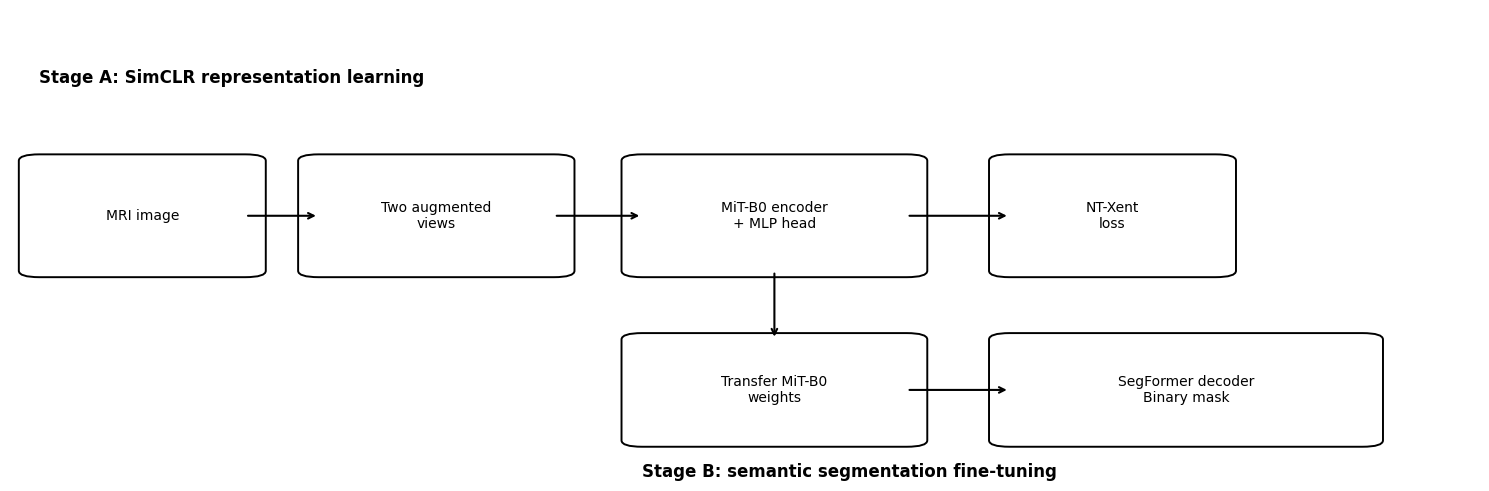

In [6]:
# ============================================================
# 6. Workflow diagram: direct MiT-B0 encoder transfer
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))
ax.axis("off")

nodes = [
    (0.02, 0.43, 0.14, 0.24, "MRI image"),
    (0.21, 0.43, 0.16, 0.24, "Two augmented\nviews"),
    (0.43, 0.43, 0.18, 0.24, "MiT-B0 encoder\n+ MLP head"),
    (0.68, 0.43, 0.14, 0.24, "NT-Xent\nloss"),
    (0.43, 0.06, 0.18, 0.22, "Transfer MiT-B0\nweights"),
    (0.68, 0.06, 0.24, 0.22, "SegFormer decoder\nBinary mask"),
]

for x, y, w, h, label in nodes:
    patch = FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.014",
        facecolor="white", edgecolor="black", linewidth=1.4
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=10)

style = dict(arrowstyle="->", linewidth=1.5)
ax.annotate("", xy=(0.21, 0.55), xytext=(0.16, 0.55), arrowprops=style)
ax.annotate("", xy=(0.43, 0.55), xytext=(0.37, 0.55), arrowprops=style)
ax.annotate("", xy=(0.68, 0.55), xytext=(0.61, 0.55), arrowprops=style)
ax.annotate("", xy=(0.52, 0.28), xytext=(0.52, 0.43), arrowprops=style)
ax.annotate("", xy=(0.68, 0.17), xytext=(0.61, 0.17), arrowprops=style)

ax.text(0.02, 0.84, "Stage A: SimCLR representation learning", fontsize=12, fontweight="bold")
ax.text(0.43, -0.02, "Stage B: semantic segmentation fine-tuning", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.output_dir / "workflow_direct_encoder_transfer.png", dpi=180, bbox_inches="tight")
plt.show()


## Stage A · SimCLR on the MiT-B0 encoder

`SegformerModel` is the bare MiT encoder. It is used directly with an MLP projection head for contrastive learning. If `nvidia/mit-b0` is accessible in the Kaggle session, the notebook performs self-supervised domain adaptation from published MiT-B0 weights to MRI images. If that checkpoint is unavailable, the notebook falls back to a randomly initialised MiT-B0 encoder while retaining the same transfer experiment.

In [7]:
# ============================================================
# 7. MiT-B0 SimCLR model and stable NT-Xent loss
# ============================================================

def load_mit_encoder(checkpoint: str) -> Tuple[SegformerModel, str]:
    try:
        encoder = SegformerModel.from_pretrained(checkpoint)
        note = f"Loaded '{checkpoint}'; SimCLR performs MRI-domain adaptation."
    except Exception as error:
        print("Published MiT-B0 weights could not be retrieved in this session.")
        print("Diagnostic message:", error)
        print("Using randomly initialised MiT-B0 while preserving direct transfer.")
        encoder = SegformerModel(SegformerConfig())
        note = "Randomly initialised MiT-B0 used because checkpoint retrieval failed."
    return encoder, note


def global_pool(last_hidden_state: torch.Tensor) -> torch.Tensor:
    if last_hidden_state.ndim == 4:       # [B, C, H, W]
        return last_hidden_state.mean(dim=(-2, -1))
    if last_hidden_state.ndim == 3:       # [B, tokens, C]
        return last_hidden_state.mean(dim=1)
    raise RuntimeError(f"Unexpected SegFormer output shape: {last_hidden_state.shape}")


class SegFormerSimCLR(nn.Module):
    def __init__(self, encoder: SegformerModel, projection_dim: int):
        super().__init__()
        self.encoder = encoder
        hidden_dim = int(encoder.config.hidden_sizes[-1])
        self.projector = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, projection_dim),
        )

    def forward(self, images: torch.Tensor):
        output = self.encoder(pixel_values=images, return_dict=True)
        features = global_pool(output.last_hidden_state)
        projections = self.projector(features)
        return features, projections


def nt_xent_loss(z_a: torch.Tensor, z_b: torch.Tensor, temperature: float):
    """
    Stable NT-Xent implementation.

    Encoder outputs may be float16 under AMP. Similarity logits, diagonal
    masking, and cross entropy are explicitly calculated in float32; hence
    the mask does not attempt to write -1e9 into a half-precision tensor.
    """
    if z_a.shape != z_b.shape:
        raise ValueError("Both SimCLR views must produce matching projection shapes.")

    batch_size = z_a.size(0)
    if batch_size < 2:
        raise ValueError("NT-Xent needs at least two images per batch; use drop_last=True.")

    with torch.autocast(device_type=z_a.device.type, enabled=False):
        z_a = F.normalize(z_a.float(), dim=1)
        z_b = F.normalize(z_b.float(), dim=1)
        representations = torch.cat([z_a, z_b], dim=0)

        similarities = representations @ representations.T
        logits = similarities / float(temperature)
        total = 2 * batch_size

        indices = torch.arange(total, device=representations.device)
        targets = (indices + batch_size) % total
        diagonal = torch.eye(total, dtype=torch.bool, device=representations.device)
        logits = logits.masked_fill(diagonal, torch.finfo(logits.dtype).min)

        loss = F.cross_entropy(logits, targets)
        positive_similarity = similarities[indices, targets].mean().detach()

        positive_mask = torch.zeros_like(diagonal)
        positive_mask[indices, targets] = True
        negative_similarity = similarities[~(diagonal | positive_mask)].mean().detach()

    return loss, positive_similarity, negative_similarity


encoder, initialisation_note = load_mit_encoder(cfg.backbone_checkpoint)
print(initialisation_note)

# Preserve the initial representation for later t-SNE and response-map comparison.
initial_encoder = copy.deepcopy(encoder).cpu().eval()

simclr_model = SegFormerSimCLR(encoder, cfg.projection_dim).to(DEVICE)
simclr_scaler = build_grad_scaler()

print("Trainable SimCLR parameters:", f"{sum(p.numel() for p in simclr_model.parameters() if p.requires_grad):,}")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded 'nvidia/mit-b0'; SimCLR performs MRI-domain adaptation.


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Trainable SimCLR parameters: 3,418,080


In [8]:
# ============================================================
# 8. Numerical-stability smoke test and Stage A training
# ============================================================

# Smoke test: detects AMP/contrastive-objective problems before ten epochs run.
test_a, test_b = next(iter(simclr_loader))
test_a = test_a.to(DEVICE).contiguous()
test_b = test_b.to(DEVICE).contiguous()

simclr_model.train()
with torch.no_grad():
    with amp_context():
        _, test_z_a = simclr_model(test_a)
        _, test_z_b = simclr_model(test_b)
    test_loss, test_positive, test_negative = nt_xent_loss(test_z_a, test_z_b, cfg.temperature)

assert torch.isfinite(test_loss), "SimCLR smoke test produced a non-finite loss."
print(
    f"Stable NT-Xent smoke test passed | loss={test_loss.item():.4f}, "
    f"positive={test_positive.item():.4f}, negative={test_negative.item():.4f}"
)


def train_simclr_epoch(model, loader, optimizer, scaler, description):
    model.train()
    totals = {"loss": 0.0, "positive_similarity": 0.0, "negative_similarity": 0.0}
    progress = tqdm(loader, desc=description, leave=False)

    for view_a, view_b in progress:
        view_a = view_a.to(DEVICE, non_blocking=(DEVICE.type == "cuda")).contiguous()
        view_b = view_b.to(DEVICE, non_blocking=(DEVICE.type == "cuda")).contiguous()
        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            _, z_a = model(view_a)
            _, z_b = model(view_b)

        loss, positive, negative = nt_xent_loss(z_a, z_b, cfg.temperature)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite SimCLR loss detected.")

        if AMP_ENABLED:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        totals["loss"] += loss.item()
        totals["positive_similarity"] += positive.item()
        totals["negative_similarity"] += negative.item()
        progress.set_postfix(loss=f"{loss.item():.4f}", pos=f"{positive.item():.3f}", neg=f"{negative.item():.3f}")

    return {key: value / max(len(loader), 1) for key, value in totals.items()}


ssl_optimizer = torch.optim.AdamW(
    simclr_model.parameters(), lr=cfg.learning_rate_ssl, weight_decay=cfg.weight_decay
)
ssl_records = []

for epoch in tqdm(range(1, cfg.ssl_epochs + 1), desc="Stage A: SimCLR epochs"):
    metrics = train_simclr_epoch(
        simclr_model, simclr_loader, ssl_optimizer, simclr_scaler,
        f"SimCLR train {epoch}/{cfg.ssl_epochs}"
    )
    metrics["epoch"] = epoch
    ssl_records.append(metrics)
    print(
        f"Epoch {epoch:02d}/{cfg.ssl_epochs} | loss={metrics['loss']:.4f} | "
        f"positive={metrics['positive_similarity']:.4f} | "
        f"negative={metrics['negative_similarity']:.4f}"
    )

ssl_history = pd.DataFrame(ssl_records)
ssl_history.to_csv(cfg.output_dir / "simclr_history.csv", index=False)
torch.save(
    {
        "encoder_state_dict": simclr_model.encoder.state_dict(),
        "projector_state_dict": simclr_model.projector.state_dict(),
        "configuration": asdict(cfg),
        "initialisation_note": initialisation_note,
    },
    cfg.output_dir / "simclr_mit_b0_checkpoint.pt",
)
display(ssl_history.round(4))


Stable NT-Xent smoke test passed | loss=2.4954, positive=0.7720, negative=0.5370


Stage A: SimCLR epochs:   0%|          | 0/10 [00:00<?, ?it/s]

SimCLR train 1/10:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 01/10 | loss=1.1962 | positive=0.8085 | negative=0.1057


SimCLR train 2/10:   0%|          | 0/93 [00:00<?, ?it/s]

...

SimCLR train 9/10:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 09/10 | loss=0.4163 | positive=0.9355 | negative=0.0170


SimCLR train 10/10:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 10/10 | loss=0.4145 | positive=0.9388 | negative=0.0200


,loss,positive_similarity,negative_similarity,epoch
0,1.1962,0.8085,0.1057,1
1,0.7613,0.8856,0.0462,2
2,0.6070,0.9077,0.0365,3
3,0.5719,0.9131,0.0411,4
4,0.5272,0.9201,0.0291,5
5,0.4648,0.9247,0.0199,6
6,0.4483,0.9306,0.0198,7
7,0.4291,0.9315,0.0192,8
8,0.4163,0.9355,0.0170,9
9,0.4145,0.9388,0.0200,10


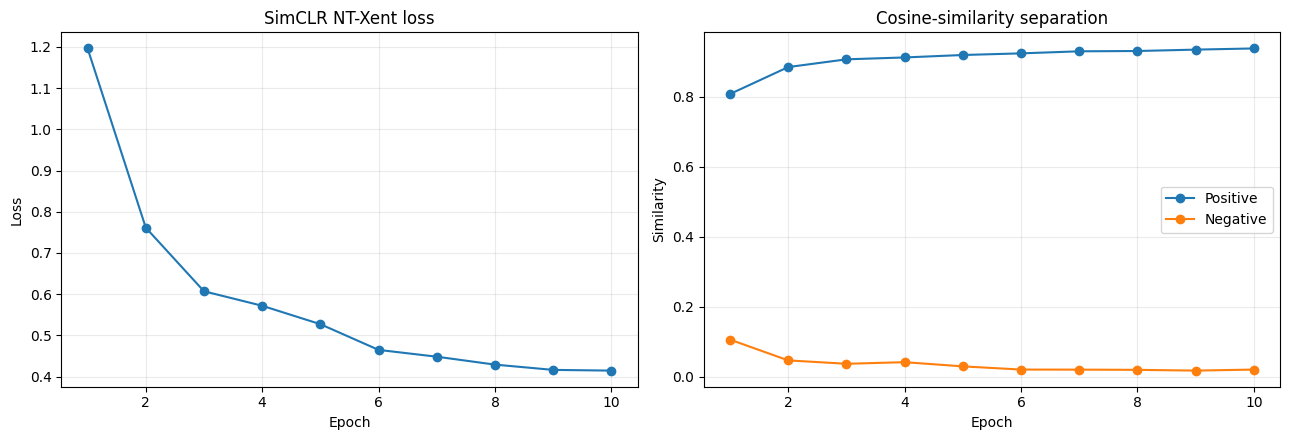

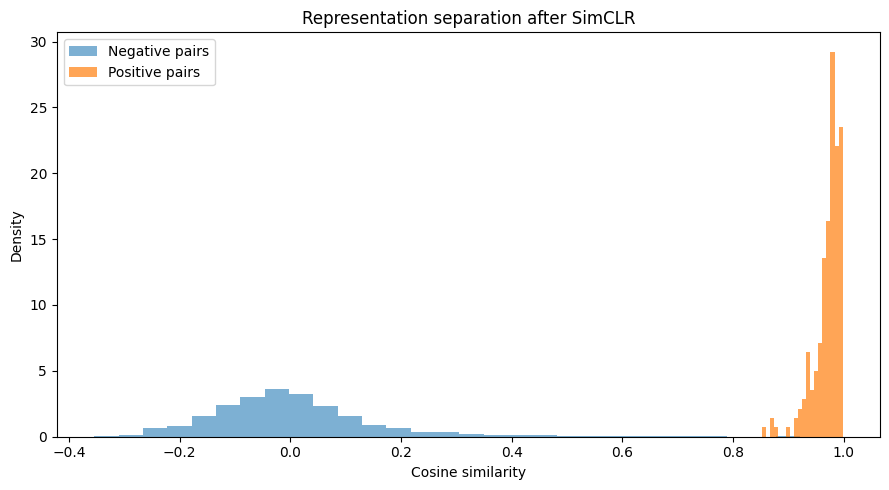

In [9]:
# ============================================================
# 9. Contrastive-learning visualisations
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ssl_history["epoch"], ssl_history["loss"], marker="o")
axes[0].set_title("SimCLR NT-Xent loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.25)

axes[1].plot(ssl_history["epoch"], ssl_history["positive_similarity"], marker="o", label="Positive")
axes[1].plot(ssl_history["epoch"], ssl_history["negative_similarity"], marker="o", label="Negative")
axes[1].set_title("Cosine-similarity separation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Similarity"); axes[1].legend(); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(cfg.output_dir / "simclr_curves.png", dpi=180)
plt.show()


@torch.no_grad()
def similarity_distribution(model, loader, maximum_batches=12):
    model.eval()
    positives, negatives = [], []
    for batch_number, (view_a, view_b) in enumerate(loader):
        if batch_number >= maximum_batches:
            break
        view_a, view_b = view_a.to(DEVICE).contiguous(), view_b.to(DEVICE).contiguous()
        with amp_context():
            _, z_a = model(view_a)
            _, z_b = model(view_b)
        z_a, z_b = F.normalize(z_a.float(), dim=1), F.normalize(z_b.float(), dim=1)
        positives.extend((z_a * z_b).sum(1).cpu().numpy())
        matrix = z_a @ z_b.T
        not_same_image = ~torch.eye(matrix.size(0), dtype=torch.bool, device=matrix.device)
        negatives.extend(matrix[not_same_image].cpu().numpy())
    return np.asarray(positives), np.asarray(negatives)


positive_values, negative_values = similarity_distribution(simclr_model, simclr_loader)
plt.figure(figsize=(9, 5))
plt.hist(negative_values, bins=30, density=True, alpha=0.58, label="Negative pairs")
plt.hist(positive_values, bins=20, density=True, alpha=0.70, label="Positive pairs")
plt.xlabel("Cosine similarity"); plt.ylabel("Density")
plt.title("Representation separation after SimCLR")
plt.legend(); plt.tight_layout()
plt.savefig(cfg.output_dir / "similarity_distribution.png", dpi=180)
plt.show()


## Stage B · SegFormer binary segmentation

The SimCLR-trained MiT-B0 state dictionary is copied into the encoder field of `SegformerForSemanticSegmentation`. SegFormer produces lower-resolution logits; therefore, each output is bilinearly resized to the mask resolution before applying loss functions and calculating metrics.

In [10]:
# ============================================================
# 10. Direct transfer into SegFormer and segmentation objective
# ============================================================

seg_config = copy.deepcopy(simclr_model.encoder.config)
seg_config.num_labels = 2
seg_config.id2label = {0: "background", 1: "tumour"}
seg_config.label2id = {"background": 0, "tumour": 1}
seg_config.semantic_loss_ignore_index = 255

segmentation_model = SegformerForSemanticSegmentation(seg_config)
transfer_result = segmentation_model.segformer.load_state_dict(
    simclr_model.encoder.state_dict(), strict=True
)
segmentation_model = segmentation_model.to(DEVICE)

print("Direct MiT-B0 transfer completed.")
print("Missing keys:", transfer_result.missing_keys)
print("Unexpected keys:", transfer_result.unexpected_keys)


def resize_logits(logits: torch.Tensor, masks: torch.Tensor) -> torch.Tensor:
    """Resize SegFormer logits to the exact target-mask resolution."""
    return F.interpolate(logits, size=tuple(masks.shape[-2:]), mode="bilinear", align_corners=False)


def foreground_dice_loss(logits: torch.Tensor, masks: torch.Tensor, smooth: float = 1.0) -> torch.Tensor:
    probabilities = torch.softmax(logits.float(), dim=1)[:, 1]
    foreground = (masks == 1).float()
    intersection = (probabilities * foreground).sum(dim=(1, 2))
    denominator = probabilities.sum(dim=(1, 2)) + foreground.sum(dim=(1, 2))
    dice = (2 * intersection + smooth) / (denominator + smooth)
    return 1 - dice.mean()


def segmentation_loss(logits: torch.Tensor, masks: torch.Tensor):
    """Cross-entropy plus tumour Dice loss, both evaluated in float32."""
    ce = F.cross_entropy(logits.float(), masks.long())
    dice_component = foreground_dice_loss(logits.float(), masks.long())
    total = cfg.ce_weight * ce + cfg.dice_weight * dice_component
    return total, ce.detach(), dice_component.detach()


Direct MiT-B0 transfer completed.
Missing keys: []
Unexpected keys: []


In [11]:
# ============================================================
# 11. SegFormer training/evaluation loop and Stage B training
# ============================================================

def run_segmentation_epoch(model, loader, training=False, optimizer=None, scaler=None, description=""):
    model.train(training)
    total_loss = total_ce = total_dice_loss = 0.0
    tp = fp = fn = correct = pixels = 0.0

    progress = tqdm(loader, desc=description, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=(DEVICE.type == "cuda")).contiguous()
        masks = masks.to(DEVICE, non_blocking=(DEVICE.type == "cuda")).contiguous()

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with amp_context():
                output = model(pixel_values=images)
                logits = resize_logits(output.logits, masks)
            loss, ce, dice_component = segmentation_loss(logits, masks)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite segmentation loss detected.")

            if training:
                if AMP_ENABLED:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        predictions = logits.detach().argmax(1)
        pred_fg, true_fg = predictions == 1, masks == 1
        tp += (pred_fg & true_fg).sum().item()
        fp += (pred_fg & ~true_fg).sum().item()
        fn += (~pred_fg & true_fg).sum().item()
        correct += (predictions == masks).sum().item()
        pixels += masks.numel()

        total_loss += loss.item()
        total_ce += ce.item()
        total_dice_loss += dice_component.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    epsilon = 1e-7
    return {
        "loss": total_loss / max(len(loader), 1),
        "cross_entropy": total_ce / max(len(loader), 1),
        "dice_loss": total_dice_loss / max(len(loader), 1),
        "dice": (2 * tp) / (2 * tp + fp + fn + epsilon),
        "iou": tp / (tp + fp + fn + epsilon),
        "pixel_accuracy": correct / (pixels + epsilon),
    }


segmentation_optimizer = torch.optim.AdamW(
    segmentation_model.parameters(),
    lr=cfg.learning_rate_segmentation,
    weight_decay=cfg.weight_decay,
)
segmentation_scaler = build_grad_scaler()
records = []
best_dice = -1.0
best_path = cfg.output_dir / "best_segformer_binary_model.pt"

for epoch in tqdm(range(1, cfg.segmentation_epochs + 1), desc="Stage B: SegFormer epochs"):
    train_metrics = run_segmentation_epoch(
        segmentation_model, train_loader, training=True,
        optimizer=segmentation_optimizer, scaler=segmentation_scaler,
        description=f"Train {epoch}/{cfg.segmentation_epochs}"
    )
    valid_metrics = run_segmentation_epoch(
        segmentation_model, valid_loader, training=False,
        description=f"Valid {epoch}/{cfg.segmentation_epochs}"
    )

    row = {"epoch": epoch}
    row.update({f"train_{key}": value for key, value in train_metrics.items()})
    row.update({f"valid_{key}": value for key, value in valid_metrics.items()})
    records.append(row)

    print(
        f"Epoch {epoch:02d}/{cfg.segmentation_epochs} | "
        f"train loss={train_metrics['loss']:.4f} | valid loss={valid_metrics['loss']:.4f} | "
        f"Dice={valid_metrics['dice']:.4f} | IoU={valid_metrics['iou']:.4f} | "
        f"pixel acc.={valid_metrics['pixel_accuracy']:.4f}"
    )

    if valid_metrics["dice"] > best_dice:
        best_dice = valid_metrics["dice"]
        torch.save({"model_state_dict": segmentation_model.state_dict(), "best_dice": best_dice}, best_path)

history = pd.DataFrame(records)
history.to_csv(cfg.output_dir / "segmentation_history.csv", index=False)
display(history.round(4))
print("Best validation Dice:", round(best_dice, 4))


Stage B: SegFormer epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train 1/10:   0%|          | 0/188 [00:00<?, ?it/s]

Valid 1/10:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 01/10 | train loss=0.7658 | valid loss=0.4532 | Dice=0.6816 | IoU=0.5170 | pixel acc.=0.9765


Train 2/10:   0%|          | 0/188 [00:00<?, ?it/s]

...

Train 10/10:   0%|          | 0/188 [00:00<?, ?it/s]

Valid 10/10:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 10/10 | train loss=0.2672 | valid loss=0.3158 | Dice=0.7693 | IoU=0.6251 | pixel acc.=0.9832


,epoch,train_loss,train_cross_entropy,train_dice_loss,train_dice,train_iou,train_pixel_accuracy,valid_loss,valid_cross_entropy,valid_dice_loss,valid_dice,valid_iou,valid_pixel_accuracy
0,1,0.7658,0.1653,0.6006,0.5216,0.3529,0.9518,0.4532,0.0676,0.3856,0.6816,0.5170,0.9765
1,2,0.4208,0.0711,0.3497,0.6973,0.5353,0.9767,0.4122,0.0711,0.3411,0.7021,0.5409,0.9762
2,3,0.3682,0.0645,0.3038,0.7304,0.5753,0.9794,0.3442,0.0660,0.2783,0.7296,0.5743,0.9782
3,4,0.3339,0.0592,0.2747,0.7517,0.6022,0.9813,0.3830,0.0716,0.3114,0.7222,0.5652,0.9804
4,5,0.3130,0.0558,0.2572,0.7697,0.6256,0.9827,0.3102,0.0601,0.2502,0.7657,0.6204,0.9828
5,6,0.2923,0.0528,0.2395,0.7837,0.6443,0.9838,0.3362,0.0639,0.2723,0.7633,0.6172,0.9825
6,7,0.2849,0.0517,0.2332,0.7918,0.6554,0.9844,0.3273,0.0672,0.2602,0.7605,0.6136,0.9818
7,8,0.2633,0.0480,0.2153,0.8078,0.6776,0.9856,0.3383,0.0702,0.2681,0.7603,0.6132,0.9816
8,9,0.2648,0.0475,0.2173,0.8063,0.6755,0.9855,0.3169,0.0633,0.2535,0.7678,0.6231,0.9827
9,10,0.2672,0.0486,0.2187,0.7997,0.6663,0.9849,0.3158,0.0645,0.2512,0.7693,0.6251,0.9832


Best validation Dice: 0.7693


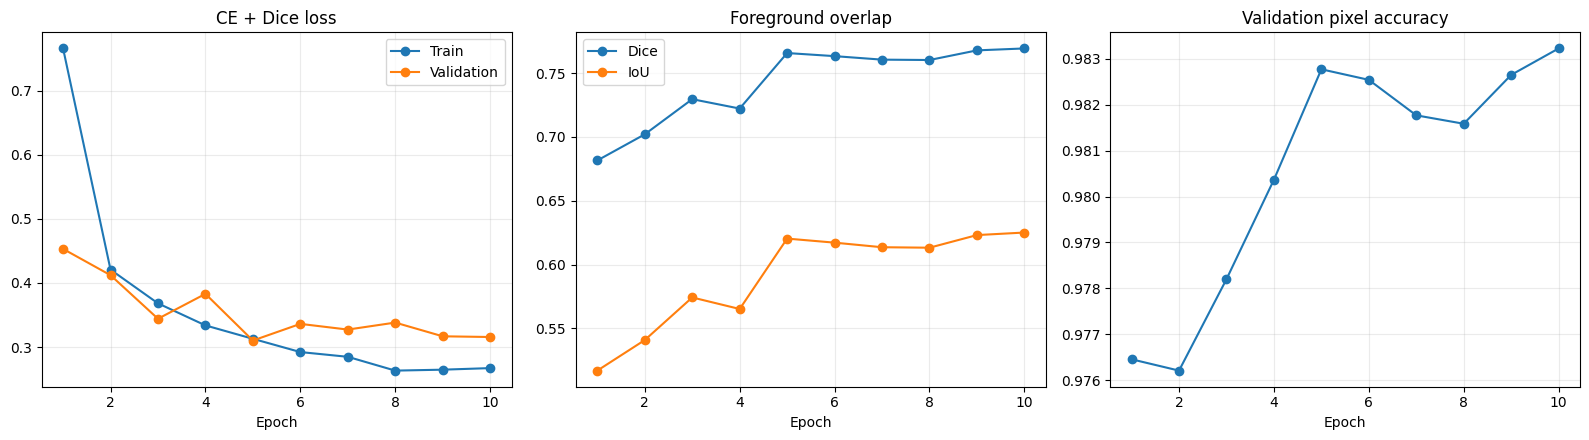

Test evaluation:   0%|          | 0/27 [00:00<?, ?it/s]

,Metric,Value
0,loss,0.3265
1,cross_entropy,0.0687
2,dice_loss,0.2577
3,dice,0.7492
4,iou,0.5990
5,pixel_accuracy,0.9819


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
# ============================================================
# 12. Segmentation curves and held-out test results
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="Train")
axes[0].plot(history["epoch"], history["valid_loss"], marker="o", label="Validation")
axes[0].set_title("CE + Dice loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(history["epoch"], history["valid_dice"], marker="o", label="Dice")
axes[1].plot(history["epoch"], history["valid_iou"], marker="o", label="IoU")
axes[1].set_title("Foreground overlap"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.25)

axes[2].plot(history["epoch"], history["valid_pixel_accuracy"], marker="o")
axes[2].set_title("Validation pixel accuracy"); axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(cfg.output_dir / "segmentation_curves.png", dpi=180)
plt.show()

checkpoint = torch.load(best_path, map_location=DEVICE)
segmentation_model.load_state_dict(checkpoint["model_state_dict"])

test_metrics = run_segmentation_epoch(
    segmentation_model, test_loader, training=False, description="Test evaluation"
)
test_table = pd.DataFrame({"Metric": list(test_metrics.keys()), "Value": list(test_metrics.values())})
display(test_table.round(4))
test_table.to_csv(cfg.output_dir / "test_metrics.csv", index=False)
segmentation_model.save_pretrained(cfg.output_dir / "segformer_binary_model")

with open(cfg.output_dir / "run_summary.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "initialisation_note": initialisation_note,
            "device": str(DEVICE),
            "amp_enabled": AMP_ENABLED,
            "best_validation_dice": float(best_dice),
            "test_metrics": test_metrics,
        },
        handle, indent=2
    )


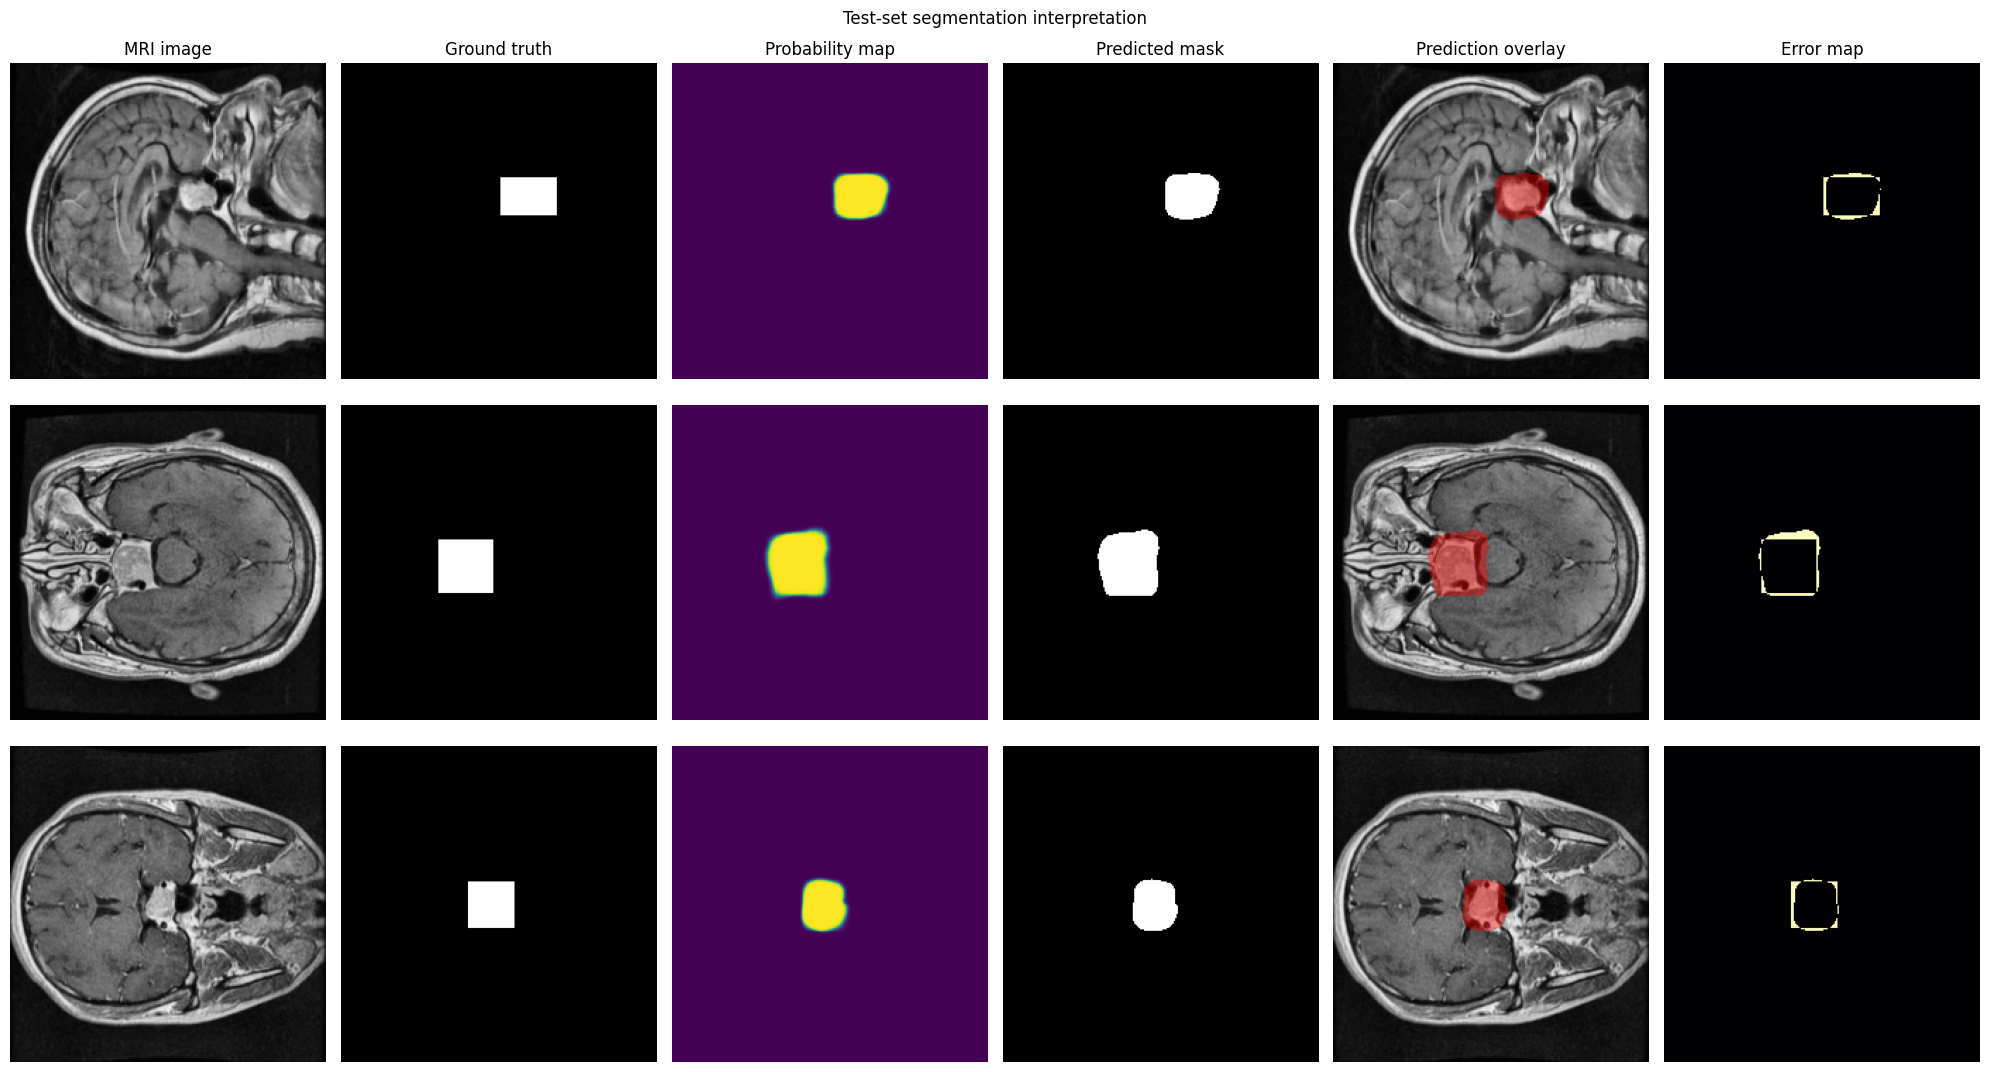

In [13]:
# ============================================================
# 13. Qualitative prediction panels
# MRI | ground truth | probability | prediction | overlay | error
# ============================================================

@torch.no_grad()
def gather_examples(model, loader, requested=3):
    model.eval()
    examples = []
    for images, masks, names in loader:
        images_device = images.to(DEVICE).contiguous()
        masks_device = masks.to(DEVICE).contiguous()
        with amp_context():
            logits = resize_logits(model(pixel_values=images_device).logits, masks_device)
        probabilities = torch.softmax(logits.float(), dim=1)[:, 1].cpu()
        predictions = (probabilities >= cfg.probability_threshold).long()
        for i in range(images.size(0)):
            examples.append(
                {
                    "image": denormalize(images[i]),
                    "mask": masks[i].numpy(),
                    "probability": probabilities[i].numpy(),
                    "prediction": predictions[i].numpy(),
                    "name": names[i],
                }
            )
            if len(examples) == requested:
                return examples
    return examples


examples = gather_examples(segmentation_model, test_loader, requested=min(3, len(test_dataset)))
fig, axes = plt.subplots(len(examples), 6, figsize=(20, 3.7 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, 0)

for row, example in enumerate(examples):
    image = (example["image"] * 255).astype(np.uint8)
    mask = example["mask"]
    probability = example["probability"]
    prediction = example["prediction"]
    error = (prediction != mask).astype(np.uint8)

    panels = [
        (image, None, "MRI image"),
        (mask, "gray", "Ground truth"),
        (probability, "viridis", "Probability map"),
        (prediction, "gray", "Predicted mask"),
        (overlay_mask(image, prediction), None, "Prediction overlay"),
        (error, "magma", "Error map"),
    ]
    for column, (panel, cmap, title) in enumerate(panels):
        axes[row, column].imshow(panel, cmap=cmap, vmin=0 if cmap else None)
        if row == 0:
            axes[row, column].set_title(title)
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(example["name"], fontsize=8)

plt.suptitle("Test-set segmentation interpretation")
plt.tight_layout()
plt.savefig(cfg.output_dir / "qualitative_test_predictions.png", dpi=180, bbox_inches="tight")
plt.show()


## Reading the qualitative visualisations

The probability map should be examined before the thresholded mask. It exposes uncertainty at tumour boundaries and small suspected regions that may disappear after thresholding. The error map identifies disagreement with the annotation; comparison with the ground-truth mask is needed to distinguish false-positive from false-negative pixels.

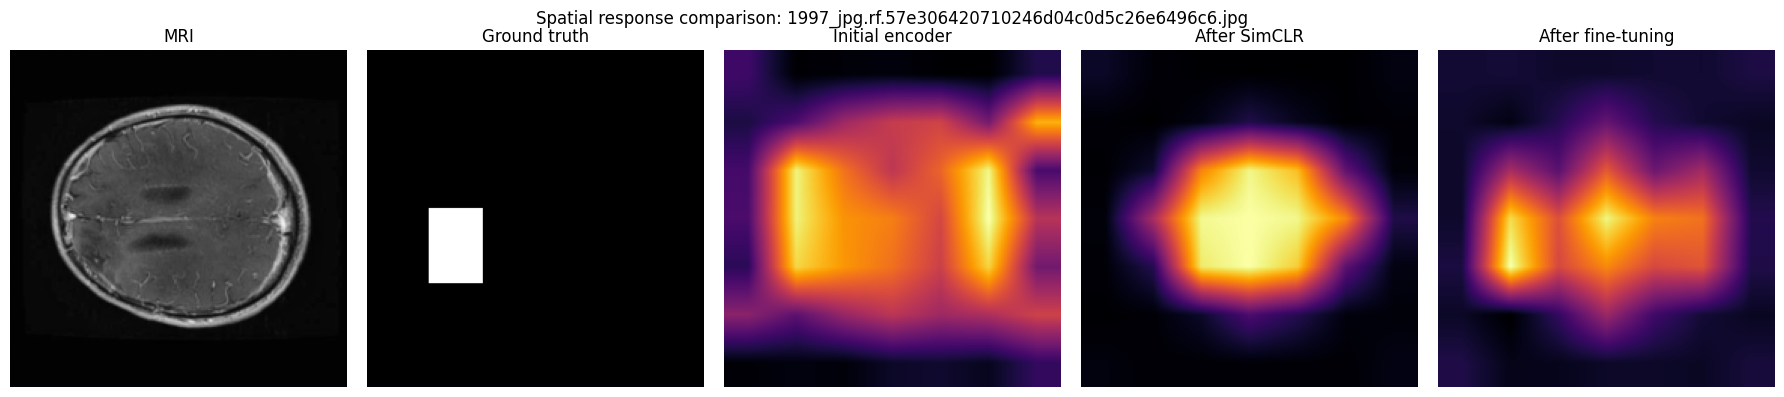

In [14]:
# ============================================================
# 14. Spatial feature-response maps at three learning stages
# ============================================================

@torch.no_grad()
def response_map(encoder: SegformerModel, image: torch.Tensor, output_size: Tuple[int, int]) -> np.ndarray:
    encoder.eval()
    with amp_context():
        hidden = encoder(pixel_values=image.unsqueeze(0).to(DEVICE).contiguous(), return_dict=True).last_hidden_state.float()

    if hidden.ndim == 4:
        response = hidden.abs().mean(dim=1, keepdim=True)
    elif hidden.ndim == 3:
        side = int(math.sqrt(hidden.size(1)))
        response = hidden[:, :side * side].abs().mean(dim=2).reshape(1, 1, side, side)
    else:
        raise RuntimeError(f"Unsupported feature map shape: {hidden.shape}")

    response = F.interpolate(response, size=output_size, mode="bilinear", align_corners=False)[0, 0]
    response = response - response.min()
    response = response / (response.max() + 1e-8)
    return response.cpu().numpy()


initial_encoder = initial_encoder.to(DEVICE).eval()
simclr_encoder = simclr_model.encoder.to(DEVICE).eval()
fine_tuned_encoder = segmentation_model.segformer.to(DEVICE).eval()

feature_image, feature_mask, feature_name = valid_dataset[0]
maps = [
    response_map(initial_encoder, feature_image, tuple(feature_mask.shape)),
    response_map(simclr_encoder, feature_image, tuple(feature_mask.shape)),
    response_map(fine_tuned_encoder, feature_image, tuple(feature_mask.shape)),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(denormalize(feature_image)); axes[0].set_title("MRI")
axes[1].imshow(feature_mask.numpy(), cmap="gray", vmin=0, vmax=1); axes[1].set_title("Ground truth")
for axis, image_map, title in zip(axes[2:], maps, ["Initial encoder", "After SimCLR", "After fine-tuning"]):
    axis.imshow(image_map, cmap="inferno", vmin=0, vmax=1)
    axis.set_title(title)
for axis in axes:
    axis.axis("off")
plt.suptitle(f"Spatial response comparison: {feature_name}")
plt.tight_layout()
plt.savefig(cfg.output_dir / "spatial_feature_response_maps.png", dpi=180)
plt.show()


The spatial response map averages the magnitude of final encoder features. It is a teaching visualisation of changing feature response, not a clinical explanation or a substitute for formal model-interpretability analysis.

Extracting features:   0%|          | 0/54 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/54 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/54 [00:00<?, ?it/s]

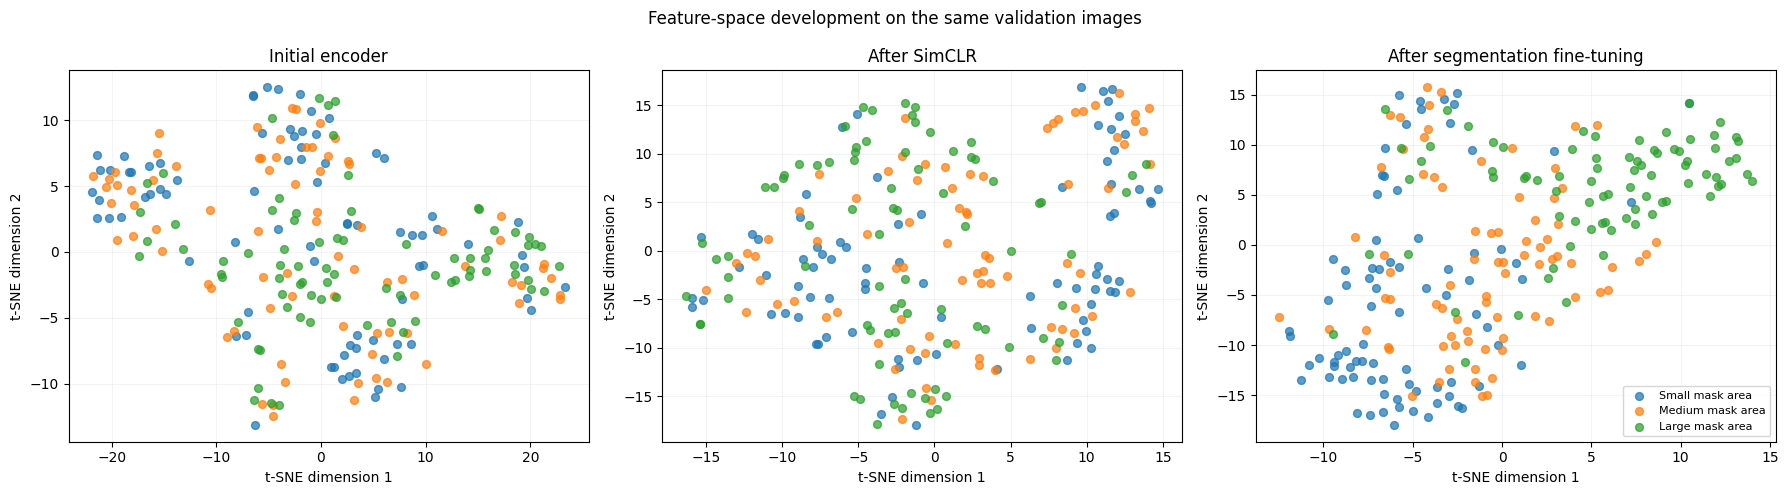

In [15]:
# ============================================================
# 15. t-SNE comparison: initial encoder, after SimCLR, after fine-tuning
# ============================================================

@torch.no_grad()
def extract_features(encoder: SegformerModel, loader: DataLoader, maximum_samples: int):
    encoder.eval()
    features, ratios, names = [], [], []
    for images, masks, file_names in tqdm(loader, desc="Extracting features", leave=False):
        with amp_context():
            hidden = encoder(pixel_values=images.to(DEVICE).contiguous(), return_dict=True).last_hidden_state
        features.append(global_pool(hidden).float().cpu().numpy())
        ratios.extend(masks.float().mean(dim=(1, 2)).numpy().tolist())
        names.extend(list(file_names))
        if len(ratios) >= maximum_samples:
            break
    return np.concatenate(features, axis=0)[:maximum_samples], np.asarray(ratios[:maximum_samples]), names[:maximum_samples]


def tsne_embedding(features: np.ndarray) -> np.ndarray:
    sample_count = features.shape[0]
    if sample_count < 4:
        raise RuntimeError("At least four validation samples are required for t-SNE.")
    perplexity = min(30, max(2, (sample_count - 1) // 3))
    arguments = dict(n_components=2, perplexity=perplexity, init="pca", learning_rate="auto", random_state=cfg.seed)
    try:
        return TSNE(max_iter=1000, **arguments).fit_transform(features)
    except TypeError:
        return TSNE(n_iter=1000, **arguments).fit_transform(features)


initial_features, ratios, names = extract_features(initial_encoder, valid_loader, cfg.tsne_max_samples)
simclr_features, _, _ = extract_features(simclr_encoder, valid_loader, cfg.tsne_max_samples)
fine_tuned_features, _, _ = extract_features(fine_tuned_encoder, valid_loader, cfg.tsne_max_samples)

q1, q2 = np.quantile(ratios, [1/3, 2/3])
groups = np.where(ratios <= q1, "Small mask area", np.where(ratios <= q2, "Medium mask area", "Large mask area"))

embeddings = {
    "Initial encoder": tsne_embedding(initial_features),
    "After SimCLR": tsne_embedding(simclr_features),
    "After segmentation fine-tuning": tsne_embedding(fine_tuned_features),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, (stage, coordinates) in zip(axes, embeddings.items()):
    for group in ["Small mask area", "Medium mask area", "Large mask area"]:
        selected = groups == group
        axis.scatter(coordinates[selected, 0], coordinates[selected, 1], s=32, alpha=0.72, label=group)
    axis.set_title(stage)
    axis.set_xlabel("t-SNE dimension 1"); axis.set_ylabel("t-SNE dimension 2")
    axis.grid(alpha=0.15)
axes[-1].legend(fontsize=8)
plt.suptitle("Feature-space development on the same validation images")
plt.tight_layout()
plt.savefig(cfg.output_dir / "tsne_three_learning_stages.png", dpi=180)
plt.show()

pd.DataFrame(
    {
        "file_name": names,
        "foreground_ratio": ratios,
        "mask_area_group": groups,
        "initial_x": embeddings["Initial encoder"][:, 0],
        "initial_y": embeddings["Initial encoder"][:, 1],
        "simclr_x": embeddings["After SimCLR"][:, 0],
        "simclr_y": embeddings["After SimCLR"][:, 1],
        "fine_tuned_x": embeddings["After segmentation fine-tuning"][:, 0],
        "fine_tuned_y": embeddings["After segmentation fine-tuning"][:, 1],
    }
).to_csv(cfg.output_dir / "tsne_coordinates.csv", index=False)


## t-SNE interpretation

t-SNE is used as an exploratory classroom visualisation. Any apparent grouping after fine-tuning should be interpreted cautiously because the embedding is nonlinear and does not measure segmentation accuracy. Dice, IoU, probability maps, and error maps remain the principal evidence for assessing tumour-region prediction.

In [16]:
# ============================================================
# 16. Output inventory
# ============================================================

saved_files = sorted(path.relative_to(cfg.output_dir) for path in cfg.output_dir.rglob("*"))
print("Saved outputs under:", cfg.output_dir)
for path in saved_files:
    print(" -", path)

print("\nNotebook execution complete.")


Saved outputs under: /kaggle/working/NB03_SimCLR_SegFormer_B0_outputs
 - best_segformer_binary_model.pt
 - mask_coverage_distribution.png
 - qualitative_test_predictions.png
 - raw_mask_overlays.png
 - run_summary.json
 - segformer_binary_model
 - segformer_binary_model/config.json
 - segformer_binary_model/model.safetensors
 - segmentation_curves.png
 - segmentation_history.csv
 - simclr_curves.png
 - simclr_history.csv
 - simclr_mit_b0_checkpoint.pt
 - simclr_views.png
 - similarity_distribution.png
 - spatial_feature_response_maps.png
 - test_metrics.csv
 - tsne_coordinates.csv
 - tsne_three_learning_stages.png
 - workflow_direct_encoder_transfer.png

Notebook execution complete.


## References

1. Xie, E., Wang, W., Yu, Z., Anandkumar, A., Alvarez, J. M., & Luo, P. (2021). *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*. NeurIPS.
2. Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. (2020). *A Simple Framework for Contrastive Learning of Visual Representations*. ICML.
3. Hugging Face Transformers Documentation. *SegFormer*.
4. PyTorch Documentation. *Automatic Mixed Precision package*.